In [1]:
import sys
print(sys.executable)

c:\Users\SATARUPA\anaconda3\envs\tf_gpu\python.exe


In [2]:
import numpy as np
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.models import load_model, clone_model
from tensorflow.keras.losses import KLDivergence, SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
# Load pre-trained teacher and student models

import tensorflow as tf
from tensorflow import keras

# Load teacher and wrap with a resize layer (224 -> 128)
teacher_base = keras.models.load_model("teacher_model_resnet50.keras")
teacher_base.trainable = False

# Create a new input at 128x128
inp = keras.Input(shape=(128, 128, 3))
resized = keras.layers.Resizing(224, 224)(inp)   # upscale to teacher's expected size
out = teacher_base(resized, training=False)

teacher = keras.Model(inputs=inp, outputs=out)   # teacher now accepts 128x128
teacher.trainable = False

original_student_model = keras.models.load_model("efficientnetb0_kd.keras")

In [4]:
# Distillation loss function
from tensorflow.keras.losses import CategoricalCrossentropy

def distillation_loss(y_true, y_pred, teacher_pred, alpha, temperature):
    cce = CategoricalCrossentropy()
    loss_ce = cce(y_true, y_pred)
    y_pred_soft = tf.nn.softmax(y_pred / temperature)
    teacher_pred_soft = tf.nn.softmax(teacher_pred / temperature)
    kldiv = KLDivergence()
    loss_kd = kldiv(teacher_pred_soft, y_pred_soft) * (temperature ** 2)
    return alpha * loss_kd + (1 - alpha) * loss_ce


In [5]:
# Training function for one curriculum region
def train_on_region(x_train, y_train, alpha, temperature, student_model, teacher_model,
                    batch_size=16, epochs=5):
    
    optimizer = Adam()
    best_loss = float('inf')
    best_weights = None
    
    dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(1000).batch(batch_size)
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        epoch_acc = 0.0
        batches = 0
        epoch_losses = []  # <--- collect losses
        for x_batch, y_batch in dataset:
            x_resized = tf.image.resize(x_batch, [128, 128])
            with tf.GradientTape() as tape:
                student_logits = student_model(x_resized, training=True)
                teacher_logits = teacher_model(x_resized, training=False)
                loss = distillation_loss(y_batch, student_logits, teacher_logits, alpha, temperature)
            grads = tape.gradient(loss, student_model.trainable_variables)
            optimizer.apply_gradients(zip(grads, student_model.trainable_variables))
            
            epoch_loss += loss.numpy()
            true_labels = tf.argmax(y_batch, axis=1)
            preds = tf.argmax(student_logits, axis=1)
            epoch_acc += tf.reduce_mean(tf.cast(tf.equal(preds, true_labels), tf.float32)).numpy()

            batches += 1
        
        epoch_loss /= batches
        epoch_acc /= batches
        epoch_losses.append(epoch_loss)  # <--- store
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")
        
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            best_weights = student_model.get_weights()
    
    student_model.set_weights(best_weights)
    return best_weights, best_loss, epoch_acc, epoch_losses  # <--- return losses

In [6]:
# Load training data for each confidence region directly
low_conf_data = np.load("low_confidence_data.npy")
low_conf_labels = np.load("low_confidence_labels.npy")

medium_conf_data = np.load("medium_confidence_data.npy")
medium_conf_labels = np.load("medium_confidence_labels.npy")
high_conf_data = np.load("high_confidence_data.npy")
high_conf_labels = np.load("high_confidence_labels.npy")

In [7]:
print("Low confidence data shape:", low_conf_data.shape)
print("Low confidence labels shape:", low_conf_labels.shape)

print("Medium confidence data shape:", medium_conf_data.shape)
print("Medium confidence labels shape:", medium_conf_labels.shape)

print("High confidence data shape:", high_conf_data.shape)
print("High confidence labels shape:", high_conf_labels.shape)


Low confidence data shape: (934, 128, 128, 3)
Low confidence labels shape: (934, 7)
Medium confidence data shape: (933, 128, 128, 3)
Medium confidence labels shape: (933, 7)
High confidence data shape: (933, 128, 128, 3)
High confidence labels shape: (933, 7)


In [8]:
# Alpha and temperature values given 
alpha_low, T_low = 0.1992, 5
alpha_med, T_med = 0.1992, 5
alpha_high, T_high = 0.2024, 5

In [9]:
# Curriculum Training Stages

student_model = keras.models.clone_model(original_student_model)
student_model.set_weights(original_student_model.get_weights())
student_model.compile()  # If needed before training

In [13]:


# Train on low confidence region


best_weights_low, loss_low, acc_low, losses_low = train_on_region(
    low_conf_data, low_conf_labels, alpha_low, T_low, student_model, teacher,batch_size=4, epochs=5)

print(f"Low confidence region training done - Loss: {loss_low:.4f}, Accuracy: {acc_low:.4f}")

: 

In [11]:
# Continue training the same student_model instance on medium confidence region
best_weights_med, loss_med, acc_med, losses_med = train_on_region(
    medium_conf_data, medium_conf_labels, alpha_med, T_med, student_model, teacher,batch_size=4, epochs=5)

print(f"Medium confidence region training done - Loss: {loss_med:.4f}, Accuracy: {acc_med:.4f}")

Epoch 1/5 - Loss: 0.5729, Accuracy: 0.7468
Epoch 2/5 - Loss: 0.4770, Accuracy: 0.7949
Epoch 3/5 - Loss: 0.4417, Accuracy: 0.8162
Epoch 4/5 - Loss: 0.4196, Accuracy: 0.8194
Epoch 5/5 - Loss: 0.3974, Accuracy: 0.8355
Medium confidence region training done - Loss: 0.3974, Accuracy: 0.8355


In [10]:
# Continue training the same student_model on high confidence region
best_weights_high, loss_high, acc_high, losses_high = train_on_region(
    high_conf_data, high_conf_labels, alpha_high, T_high, student_model,teacher,batch_size=4, epochs=5)

print(f"High confidence region training done - Loss: {loss_high:.4f}, Accuracy: {acc_high:.4f}")

Epoch 1/5 - Loss: 0.8983, Accuracy: 0.6036
Epoch 2/5 - Loss: 0.7247, Accuracy: 0.6848
Epoch 3/5 - Loss: 0.6064, Accuracy: 0.7350
Epoch 4/5 - Loss: 0.5271, Accuracy: 0.7799
Epoch 5/5 - Loss: 0.4937, Accuracy: 0.7938
High confidence region training done - Loss: 0.4937, Accuracy: 0.7938


In [42]:
# Save best weights of final training
student_model.set_weights(best_weights_low)

In [43]:
# Compile model for evaluation with proper loss and metrics
student_model.compile(
    optimizer=Adam(),
    loss=CategoricalCrossentropy(),
    metrics=['accuracy']
)

In [46]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Validation dataset path 
val_dataset_path = "C:/Users/SATARUPA/OneDrive/Desktop/Tiny ML/Hydrophobicity Classes Photos/validation"  


val_datagen = ImageDataGenerator(rescale=1./255)  
val_generator = val_datagen.flow_from_directory(
    val_dataset_path,
    target_size=(64,64), 
    batch_size=64,
    class_mode='categorical',  
    shuffle=False
)

# Evaluate on validation images
val_loss, val_acc = student_model.evaluate(val_generator, verbose=1)
print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")




Found 700 images belonging to 7 classes.
11/11 [==============================] - 1s 93ms/step - loss: 6.2565 - accuracy: 0.3429
Validation loss: 6.2565
Validation accuracy: 0.3429


In [45]:
# Save the trained student model (full model with architecture, weights, and optimizer)
student_model.save('efficientnetb0_curriculum.keras')

print("Student model saved successfully as 'efficientnetb0_curriculum.keras'")


Student model saved successfully as 'efficientnetb0_curriculum.keras'


In [48]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Validation dataset path 
val_dataset_path = "C:/Users/SATARUPA/OneDrive/Desktop/Tiny ML/Hydrophobicity Classes Photos/validation"  


val_datagen = ImageDataGenerator(rescale=1./255)  
val_generator = val_datagen.flow_from_directory(
    val_dataset_path,
    target_size=(224, 224), 
    batch_size=64,
    class_mode='categorical',  
    shuffle=False
)

# Evaluate on validation images
val_loss, val_acc = student_model.evaluate(val_generator, verbose=1)
print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")




Found 700 images belonging to 7 classes.
11/11 [==============================] - 2s 132ms/step - loss: 6.0249 - accuracy: 0.2543
Validation loss: 6.0249
Validation accuracy: 0.2543


In [16]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Validation dataset path 
val_dataset_path = "C:/Users/SATARUPA/OneDrive/Desktop/Tiny ML/Hydrophobicity Classes Photos/validation"  


val_datagen = ImageDataGenerator(rescale=1./255)  
val_generator = val_datagen.flow_from_directory(
    val_dataset_path,
    target_size=(128, 128), 
    batch_size=64,
    class_mode='categorical',  
    shuffle=False
)

# Evaluate on validation images
val_loss, val_acc = student_model.evaluate(val_generator, verbose=1)
print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")




Found 700 images belonging to 7 classes.
11/11 [==============================] - 19s 1s/step - loss: 0.1512 - accuracy: 0.9443
Validation loss: 0.1512
Validation accuracy: 0.9443


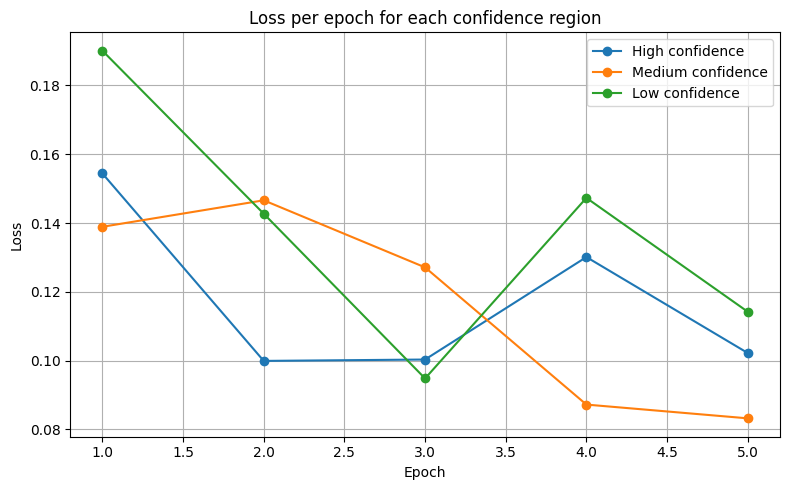

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
df = pd.read_excel("curriculumLearning1_LossAccuracy.xlsx")

# (Optional) normalize confidence names
df['Confidence zone type'] = df['Confidence zone type'].str.lower()

# Split by confidence region
df_high = df[df['Confidence zone type'] == 'high']
df_med  = df[df['Confidence zone type'] == 'medium']
df_low  = df[df['Confidence zone type'] == 'low']

plt.figure(figsize=(8, 5))

# Plot loss vs epoch for each region
plt.plot(df_high['epoch no'], df_high['Loss'], marker='o', label='High confidence')
plt.plot(df_med['epoch no'],  df_med['Loss'],  marker='o', label='Medium confidence')
plt.plot(df_low['epoch no'],  df_low['Loss'],  marker='o', label='Low confidence')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss per epoch for each confidence region')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


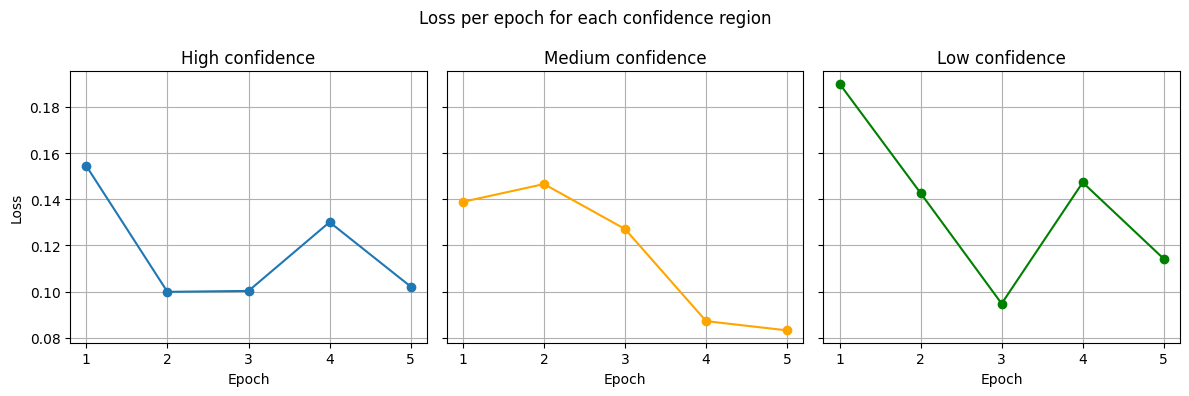

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
df = pd.read_excel("curriculumLearning1_LossAccuracy.xlsx")

# Normalize names
df['Confidence zone type'] = df['Confidence zone type'].str.lower()

# Split by confidence region
df_high = df[df['Confidence zone type'] == 'high']
df_med  = df[df['Confidence zone type'] == 'medium']
df_low  = df[df['Confidence zone type'] == 'low']

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

# High
axes[0].plot(df_high['epoch no'], df_high['Loss'], marker='o')
axes[0].set_title('High confidence')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

# Medium
axes[1].plot(df_med['epoch no'], df_med['Loss'], marker='o', color='orange')
axes[1].set_title('Medium confidence')
axes[1].set_xlabel('Epoch')
axes[1].grid(True)

# Low
axes[2].plot(df_low['epoch no'], df_low['Loss'], marker='o', color='green')
axes[2].set_title('Low confidence')
axes[2].set_xlabel('Epoch')
axes[2].grid(True)

plt.suptitle('Loss per epoch for each confidence region')
plt.tight_layout()
plt.show()


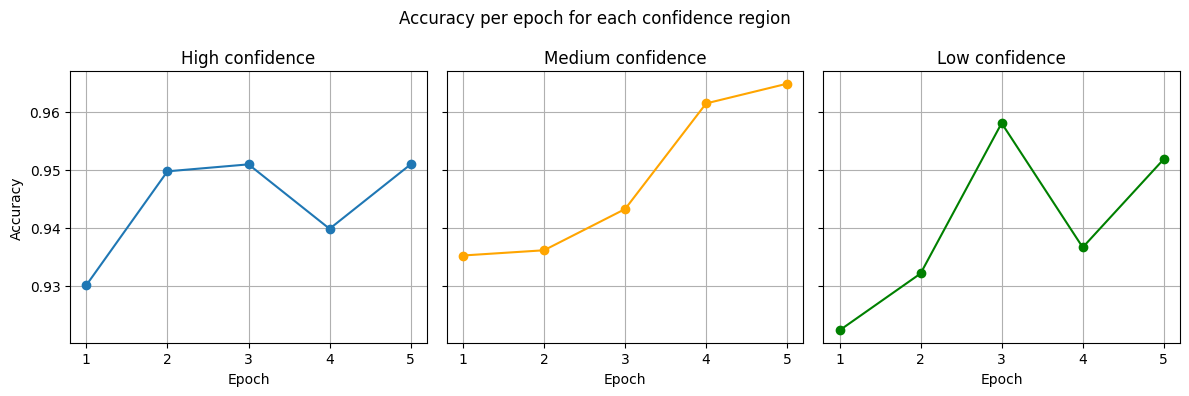

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
df = pd.read_excel("curriculumLearning1_LossAccuracy.xlsx")

# Normalize names
df['Confidence zone type'] = df['Confidence zone type'].str.lower()

# Split by confidence region
df_high = df[df['Confidence zone type'] == 'high']
df_med  = df[df['Confidence zone type'] == 'medium']
df_low  = df[df['Confidence zone type'] == 'low']

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

# High
axes[0].plot(df_high['epoch no'], df_high['Accuracy'], marker='o')
axes[0].set_title('High confidence')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True)

# Medium
axes[1].plot(df_med['epoch no'], df_med['Accuracy'], marker='o', color='orange')
axes[1].set_title('Medium confidence')
axes[1].set_xlabel('Epoch')
axes[1].grid(True)

# Low
axes[2].plot(df_low['epoch no'], df_low['Accuracy'], marker='o', color='green')
axes[2].set_title('Low confidence')
axes[2].set_xlabel('Epoch')
axes[2].grid(True)

plt.suptitle('Accuracy per epoch for each confidence region')
plt.tight_layout()
plt.show()
